

```
# This is formatted as code
```
1. Dataset Load + Clean


In [4]:
import pandas as pd

df = pd.read_csv("467.csv", sep=';')
df.columns = [c.strip() for c in df.columns]

# select important features
data = df[['CPU usage [%]',
           'Memory usage [KB]',
           'Network received throughput [KB/s]']]

2. Normalize Data

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

3. Create Time Series *Data*

In [6]:
import numpy as np

def create_dataset(dataset, time_steps=3):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:i+time_steps])
        y.append(dataset[i+time_steps])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, 3)

4. CNN + LSTM Model (Paper Based)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, MaxPooling1D, Flatten

model = Sequential()

# CNN Layer
model.add(Conv1D(filters=64, kernel_size=1, activation='relu',
                 input_shape=(X.shape[1], X.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())

# Dense (acts before LSTM in simplified version)
model.add(Dense(50, activation='relu'))

# Output layer
model.add(Dense(3))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5. Train Model

In [8]:
model.fit(X, y, epochs=20, batch_size=32)

Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0064
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0057
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0056
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0056
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0056
Epoch 7/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055
Epoch 8/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0056
Epoch 9/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055
Epoch 10/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055
Epoch 11/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055
Epoch 12/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055
Epoch 13/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055
Epoch 14/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0055
Epoch 15/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

6. Prediction

In [9]:
pred = model.predict(X)

pred = scaler.inverse_transform(pred)
actual = scaler.inverse_transform(y)

270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


7. Evaluation

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(actual, pred)
mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

MSE: 2439129933.054157
MAE: 22812.266286832226
RMSE: 49387.54836043349


8. Graph (VERY IMPORTANT FOR PRESENTATION)

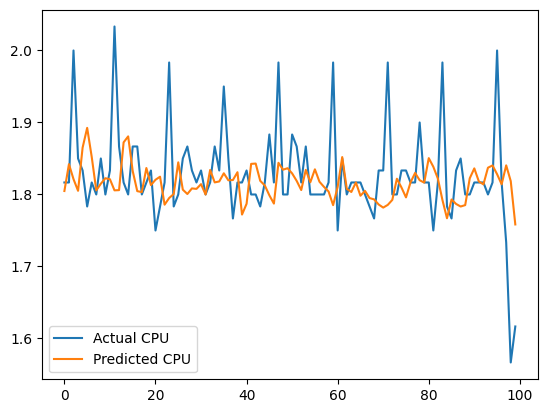

In [11]:
import matplotlib.pyplot as plt

plt.plot(actual[:100,0], label="Actual CPU")
plt.plot(pred[:100,0], label="Predicted CPU")
plt.legend()
plt.show()